In [1]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

2026-01-29 14:42:26.076074: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 14:42:26.435331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 14:42:29.577131: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
from data_degrading import degrade_spectrum
import abcsn_training
import abcsn_config

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw
from logwave import log_rebin

# Classifying Supernova Spectra With ABC-SN

# 1. Load ABC-SN

The file `ABCSN.keras` is not hosted on GitHub because it is too large of a file. You must download it from Zenodo [here](https://zenodo.org/records/16620817). Place it in `abcsn/` and ensure that it is called `ABCSN.keras`. `ABCSN.keras` has been added to `.gitignore`.

In [ ]:
abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN/abcsn/ABCSN.keras", compile=False)

# 2. Data

Importing the data from Milligan et al.


In [ ]:
cd /lustre/lrspec/users/4301/Milligan_project/data

/content/drive/MyDrive/ABC-SN/milligan_data


In [ ]:
# only unzip once
# !unzip classcomp_sample14.zip #smallest folder

In [ ]:
# just taking 10 for now
# file names and location in the drive
filename = sorted(glob.glob("/content/drive/MyDrive/ABC-SN/milligan_data/kinney_sample14/*"))
# filename

In [ ]:
file_info = [name.split("/")[-1] for name in filename]

## Extracting information from the file name:
[Host Morphology][True SN Class]Smag[SN Fibre Mag.]Gmag[Host Fibre Mag.]z[Redshift]texp[Exposure Time in Mins].txt

In [ ]:
host_types = ["elliptical", "s0", "sa", "sb", "sc", "starb1", "starb1", "starb2", "starb3", "starb4", "starb5", "starb6"]
# needs to go longest to shortest so it doesnt find II instead of IIb
# there's Iap?? not mentioned in paper

sn_class_dict = {"IIb": "IIb",
                 "IIn": "IIn",
                 "II_": "II",
                 "Iap": "Iap",
                 "Ia_": "Ia",
                 "Ic_": "Ic",
                 "Ib_": "Ib",
                 "SL_": "SL",
                 "TDE": "TDE",
                 "CRT": "CaRT"}

In [ ]:
# file_info
file_info[0]

'ellipticalIa_Smag19.012Gmag21.234z0.088028texp40.781.txt'

In [ ]:
df_metadata = pd.DataFrame(filename, columns=["filename"])
df_metadata[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]


array([[<Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'SN_mag'}>],
       [<Axes: title={'center': 'host_mag'}>, <Axes: >]], dtype=object)

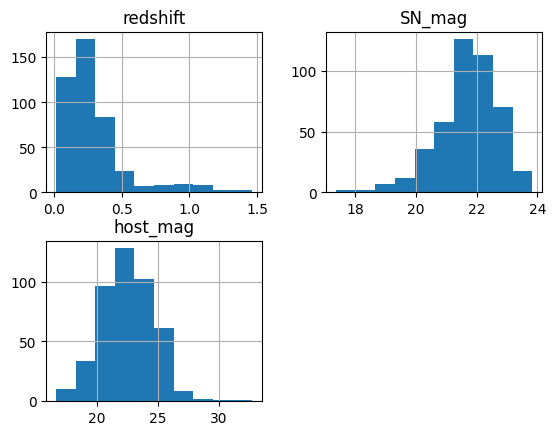

In [ ]:
df_metadata[ "host_mag"] = df_metadata[ "host_mag"].astype(float)
df_metadata[ "redshift"] = df_metadata[ "redshift"].astype(float)
df_metadata[ "SN_mag"] = df_metadata[ "SN_mag"].astype(float)
df_metadata.hist()

## processing data

Each spectrum contains five columns, wavelength (0), flux (1), flux error (2), flux with no sky subtraction (3), flux error with no sky subtraction (4).

,0,1,2,3,4
0,3671.50,-1.540120e-17,4.191180e-17,-3.098850e-18,4.191180e-17
1,3671.75,-2.458530e-17,4.182730e-17,-1.228830e-17,4.182730e-17
2,3672.00,-3.491330e-18,4.174410e-17,8.799890e-18,4.174410e-17
3,3672.25,3.297310e-17,4.166410e-17,4.526480e-17,4.166410e-17
4,3672.50,2.918540e-17,4.158060e-17,4.147270e-17,4.158060e-17


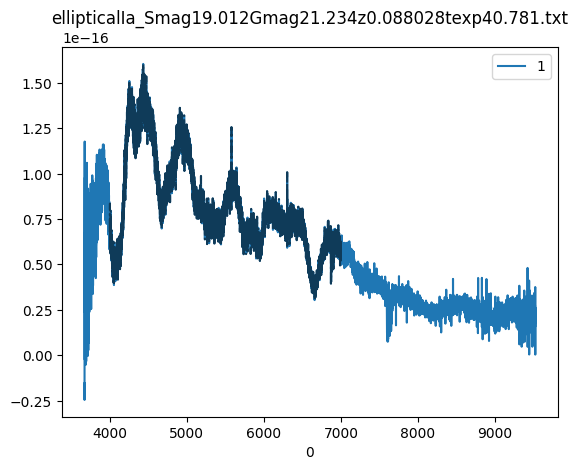

READ IN OK
meanzero
processed


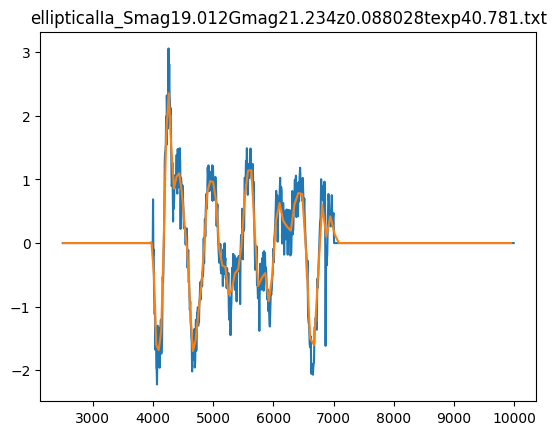

In [ ]:
# test run
wvl, X = process_files(filename[0], 4000, 7000, plot_spectra = True)

In [ ]:
# used:
# abcsn_config.SN_Stypes_int_to_str replaced with ABC_subtype_id_to_str
# to make the dictionary corresponding to the labels used above
# may just want to change the above to use the same strings as int_to_str function
ABC_subtype_id_to_str = {
    0: "Ia-norm",
    1: "Ia-91T",
    2: "Ia-91bg",
    3: "Iax",
    4: "Ib-norm",
    5: "Ibn",
    6: "IIb",
    7: "Ic-norm",
    8: "Ic-broad",
    9: "IIP",
}

ABC_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 7,
          "Ib": 4,
          "II": 9, # IIP = type 2 plateau = normal
          "IIb": 6,
          "IIn": 9,
          "SL": None,
          "TDE": None,
          "CRT": None
          }

Mill_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 1,
          "Ib": 1,
          "II": 2, # IIP = type 2 plateau = normal
          "IIb": 1,
          "IIn": 2,
          "SL": 3,
          "TDE": 4,
          "CRT": 4
          }

# five types recorded in Milligan et al.
Mill_types_to_int = {0: "Ia",
                     1: "Ib & Ic",
                     2: "II",
                     3: "SLSN",
                     4: "Non-SN",
                     5: "other"
                     }

# convert ABC types to Mill categories
ABC_to_Mill ={0:0,   # Ia-norm -> Ia
              1:0,   # Ia-91T -> Ia
              2:0,   # Ia-91bg -> Ia
              3:0,   # Iax -> Ia
              4:1,   # Ib-norm -> Ib & Ic
              5:1,   # Ibn -> Ib & Ic
              6:1,   # IIb -> Ib & Ic
              7:1,  # Ic-norm -> Ib & Ic
              8:1,  # Ic-broad -> Ib & Ic
              9:2,  # IIP -> II
            }


In [ ]:
num_wvl = 139
dat_size = len(df_metadata)
plots = False

X_all = np.zeros((dat_size, 1, num_wvl))
Y_ABC_IDs = np.zeros((dat_size)) # classification as the float classifier
Y_Mill_IDs = np.zeros((dat_size)) # classification as the float classifier

for i in tqdm(range(dat_size)):
  wvl, X = process_files(filename[i], 4000, 7000, plot_spectra = plots, verbose=False)
  X_all[i] = X
  # dont save wvl as all are the same

  try:
    Y_ABC_IDs[i] = ABC_ID_dict[df_metadata.sn_type[i]]
    Y_Mill_IDs[i] = Mill_ID_dict[df_metadata.sn_type[i]]

  except Exception as e:
    print(df_metadata.sn_type[i], i)
    raise e


df_metadata["ABC_ID"] = Y_ABC_IDs
df_metadata["Mill_ID"] = Y_Mill_IDs

# add option to save the data here


  0%|          | 1/444 [00:00<00:55,  7.94it/s]

meanzero


  0%|          | 2/444 [00:00<02:21,  3.13it/s]

meanzero


  1%|          | 3/444 [00:01<02:42,  2.71it/s]

...

meanzero


100%|█████████▉| 443/444 [01:45<00:00,  3.99it/s]

meanzero


100%|██████████| 444/444 [01:45<00:00,  4.20it/s]

meanzero


# 3. Predict

1. `X` is your array of spectra to classify.
2. `P` is your array of output probabilities of each of the 10 classes.
3. `P_argmax` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-10.
4. `P_IDs` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-16.
5. `P_str` is the final SN subtype prediction for each spectra in `X`.

In [ ]:
X = X_all.copy()
P = abcsn.predict(X, verbose=0)
P_argmax = np.argmax(P, axis=1)

In [ ]:
index = ~np.isnan(Y_ABC_IDs)

cr = (classification_report(
    Y_ABC_IDs[index],
    P_argmax[index],
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)

              precision    recall  f1-score   support

     Ia-norm       0.60      0.01      0.02       275
      Ia-91T       0.00      0.00      0.00         0
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.02      0.43      0.04         7
         Ibn       0.00      0.00      0.00         0
         IIb       0.00      0.00      0.00        16
     Ic-norm       0.01      0.14      0.02         7
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.00      0.00      0.00        88

    accuracy                           0.02       393
   macro avg       0.06      0.06      0.01       393
weighted avg       0.42      0.02      0.02       393



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def plot_cm(cm, classes, figsize=(10, 10), title=False):
    ''' Code sent to me by Fed created by Willow to plot confusion matrix
    '''
    # I removed the variable R as it was not used

    textargs = {"fontname": "Serif"}

    # Normalize confusion matrix and set image parameters
    cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]
    off_diag = ~np.eye(cm.shape[0], dtype=bool)
    cm[off_diag] *= -1
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(cm, interpolation="none", cmap="RdBu", vmin=-1, vmax=1)

    cbticks = np.linspace(-1, 1, num=9)
    cbticklabels = ["100%", "75%", "50%", "25%", "0%", "25%", "50%", "75%", "100%"]
    cb = plt.colorbar(im, shrink=0.82)
    cb.set_ticks(cbticks, labels=cbticklabels, fontsize= 12, **textargs)

    if title:
        ax.set_title(title, **textargs, fontsize=15)
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks, classes, rotation=90, **textargs, fontsize= 14)
    ax.set_yticks(tick_marks, classes, **textargs, fontsize= 14)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = np.abs(cm[i, j])
            if val == 0:
                text = ""
            elif np.isnan(val):
                text = "" # Handle NaN values
            elif val == 1:
                text = "100"
            else:
                text = f"{val*100:.1f}"
            color = "w" if val >= 0.50 else "k"
            ax.text(
                j, i, text,
                ha="center", va="center",
                c=color, **textargs, fontsize=11,
            )
    ax.set_ylabel("True label", fontsize=20, **textargs)
    ax.set_xlabel("Predicted label", fontsize=20, **textargs)

    return fig

In [ ]:
from sklearn.metrics import confusion_matrix

# confusion matrix using Mill. categories

P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])

cm = confusion_matrix(Y_Mill_IDs, P_Mill, labels=list(Mill_types_to_int.keys()))



/tmp/ipython-input-862980153.py:9: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]


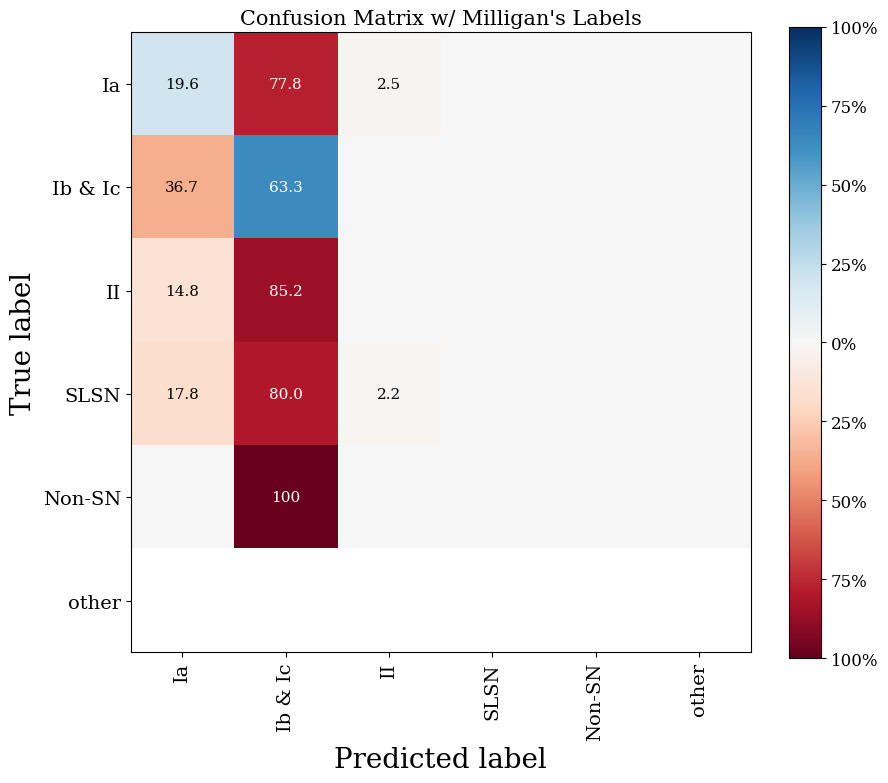

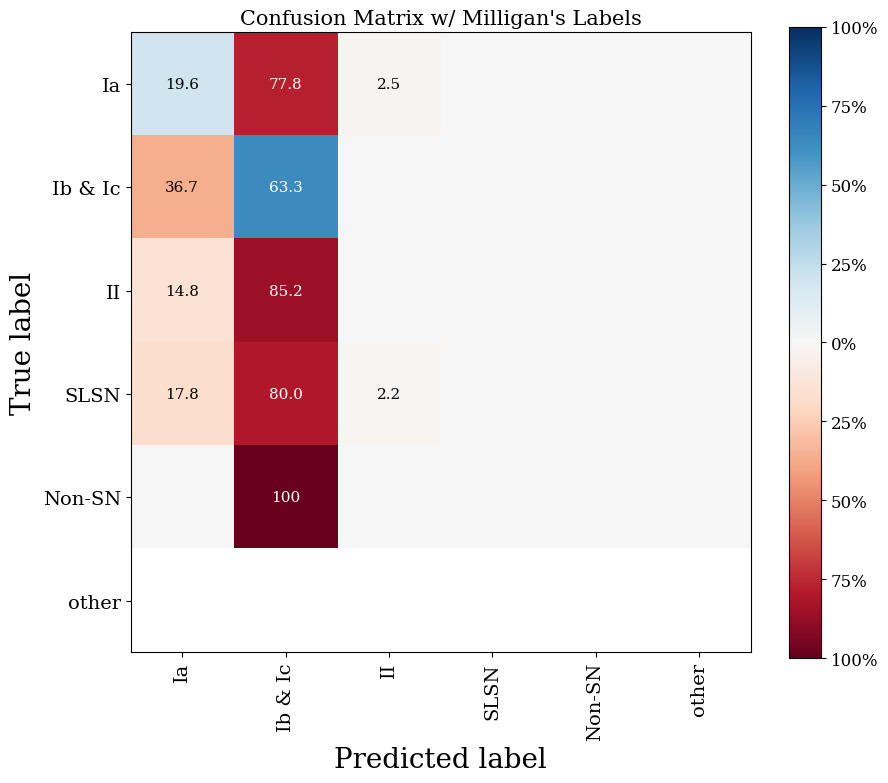

In [ ]:
plot_cm(cm, list(Mill_types_to_int.values()), title = "Confusion Matrix w/ Milligan's Labels")

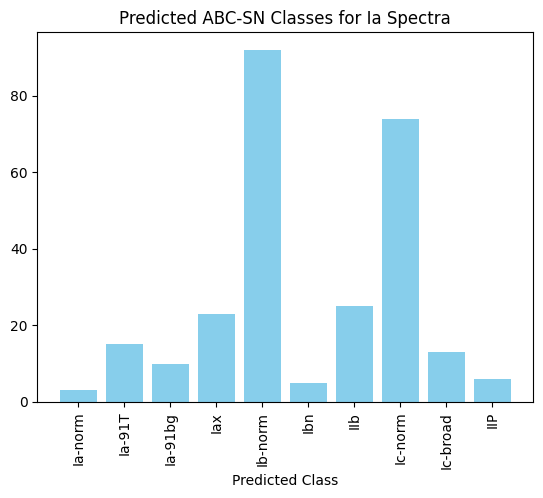

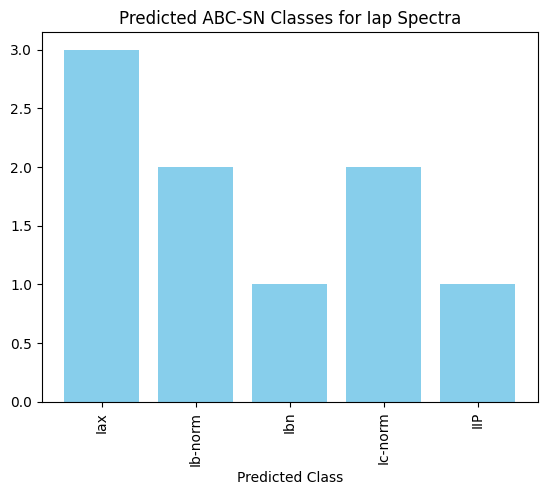

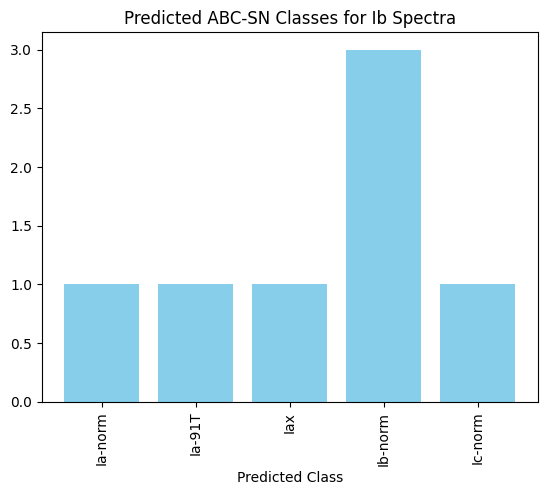

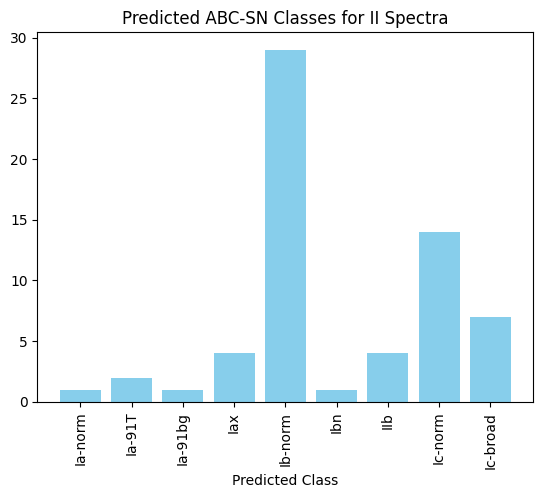

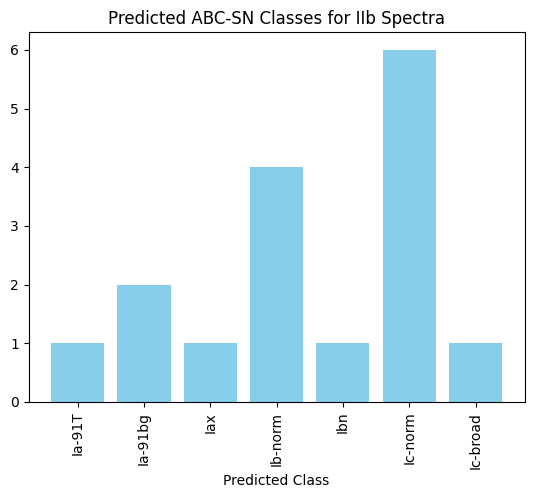

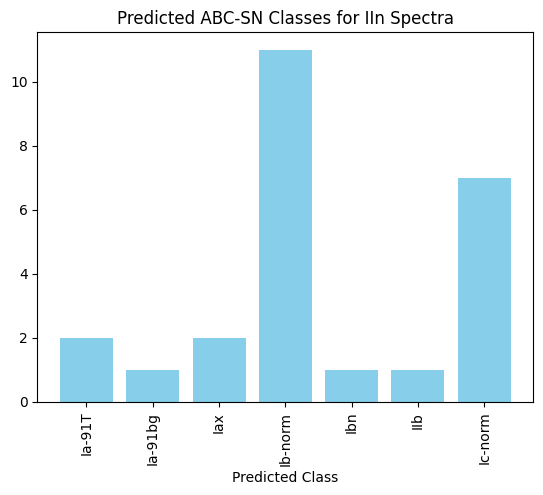

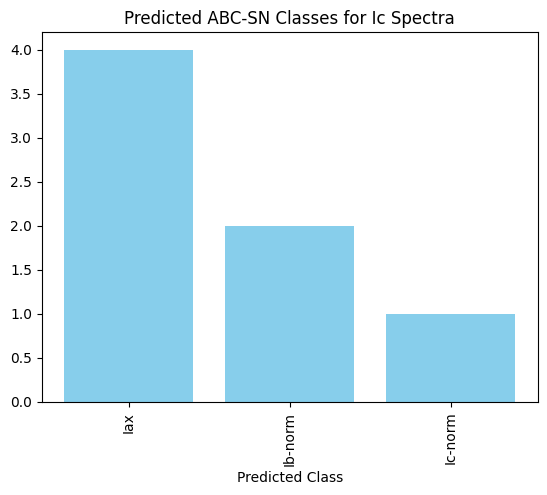

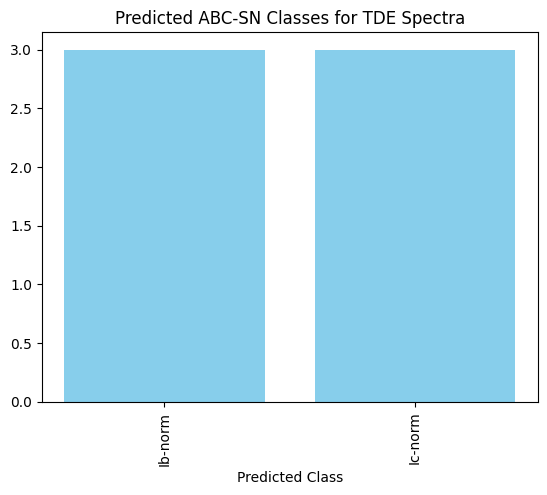

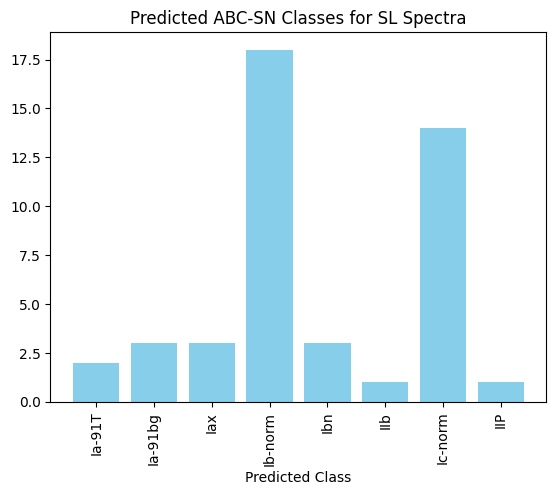

In [ ]:

for i in df_metadata.sn_type.unique():
  index = list(df_metadata.sn_type == i)
  unique, counts = np.unique(P_argmax[index], return_counts=True)
  predicted_class_labels = [list(ABC_subtype_id_to_str.values())[i] for i in unique]
  plt.bar(predicted_class_labels, counts, color='skyblue')
  plt.title(f'Predicted ABC-SN Classes for {i} Spectra')
  plt.xlabel('Predicted Class')
  plt.xticks(rotation='vertical') # Added line to rotate x-tick labels vertically
  plt.show()

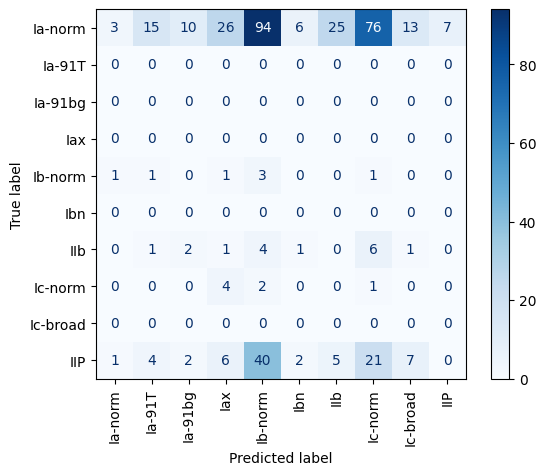

In [ ]:
index = ~np.isnan(Y_ABC_IDs)
ConfusionMatrixDisplay.from_predictions(Y_ABC_IDs[index],
    P_argmax[index],
    labels=list(ABC_subtype_id_to_str.keys()),
    display_labels=list(ABC_subtype_id_to_str.values()),
    xticks_rotation = 'vertical',
    cmap=plt.cm.Blues
    )

# chech what is 1a
# try one class at a time

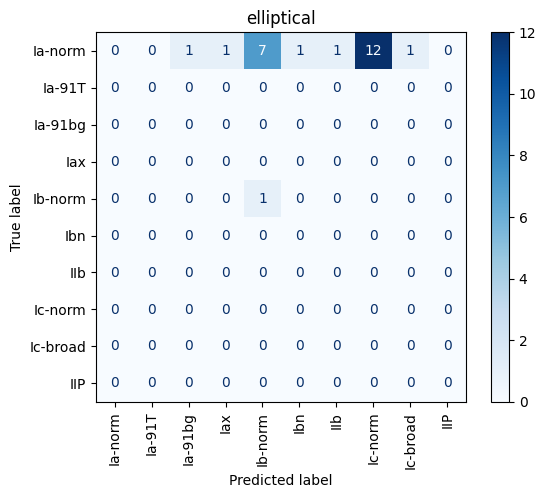

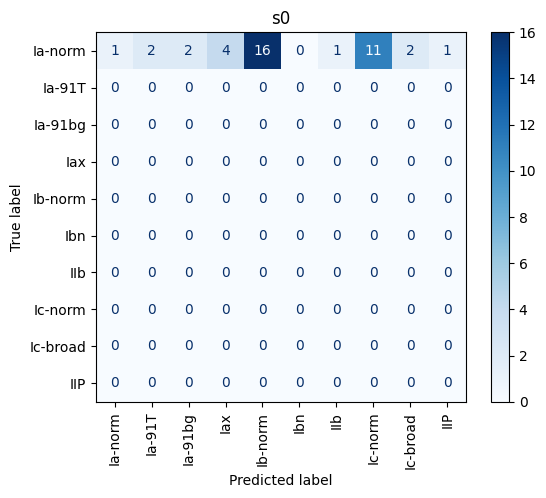

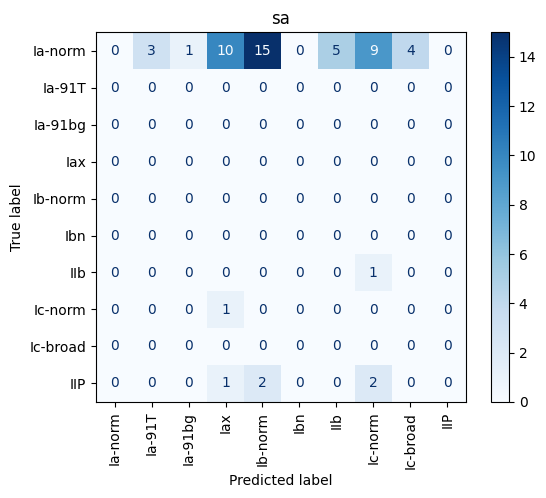

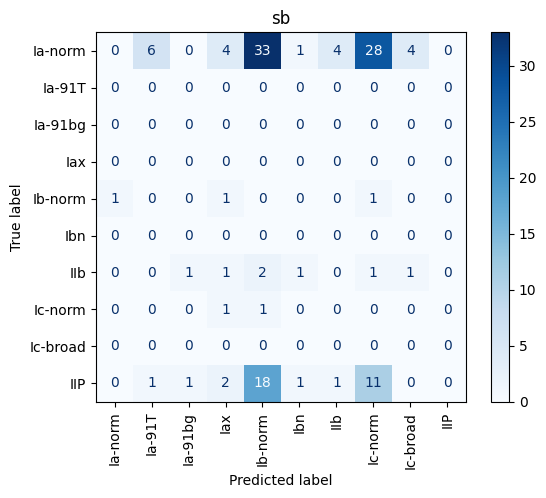

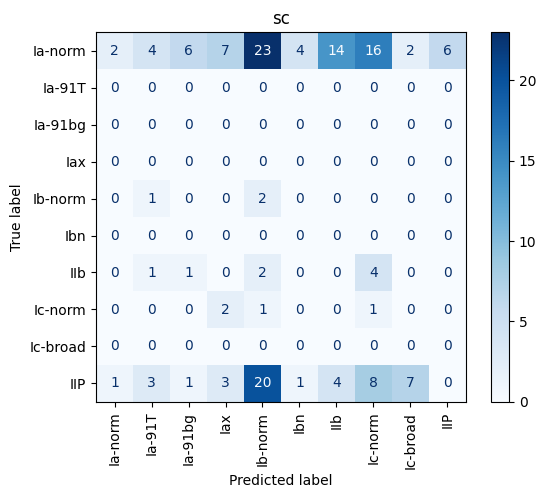

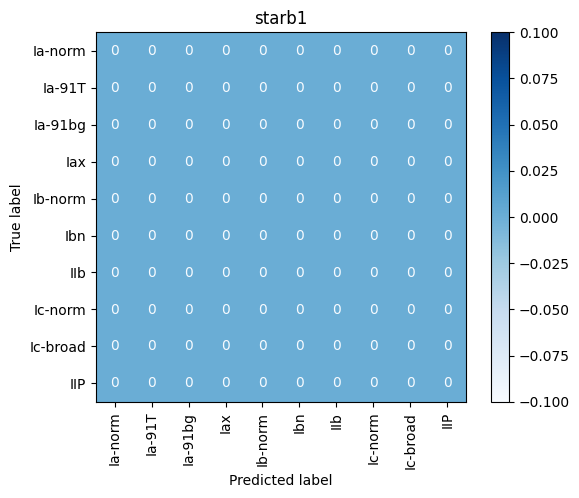

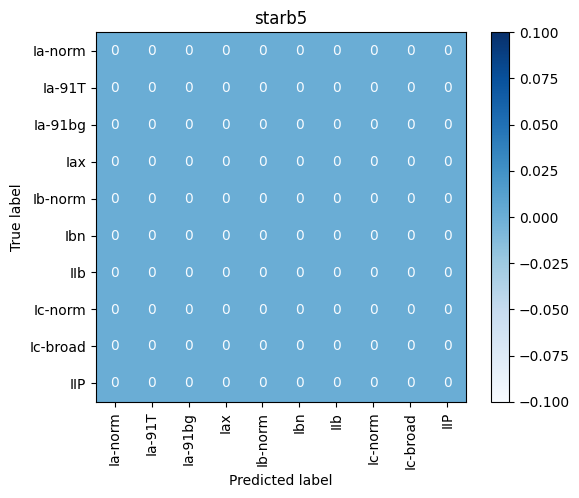

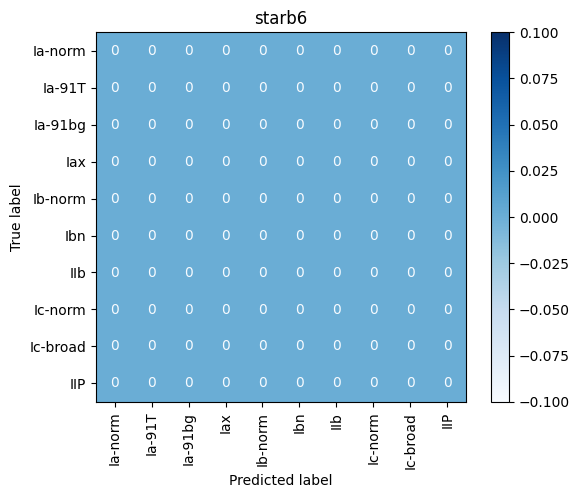

In [ ]:
for i in df_metadata.host.unique():
  index = list(df_metadata.host == i) & ~np.isnan(Y_ABC_IDs)

  disp = ConfusionMatrixDisplay.from_predictions(
          Y_ABC_IDs[index],
          P_argmax[index],
          labels=list(ABC_subtype_id_to_str.keys()),
          display_labels=list(ABC_subtype_id_to_str.values()),
          xticks_rotation = 'vertical',
          cmap=plt.cm.Blues
          )
  disp.ax_.set_title(i)
  plt.show()

# chech what is 1a
# try one class at a time

In [ ]:
df_metadata.host.value_counts()

,count
host,
sc,193
sb,127
sa,55
s0,40
elliptical,25
starb5,2
starb1,1
starb6,1
